In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid, smoothValues
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp, copyWaveSystem
from argparse import ArgumentParser

import h5py
from dataset import *

In [ ]:
parser = ArgumentParser()

parser.add_argument('--skipInitialSteps', type=int, default=0, help='Number of initial steps to skip when loading data')
parser.add_argument('--skipFinalSteps', type=int, default=0, help='Number of final steps to skip when loading data')
parser.add_argument('--temporalCoarseGrainingRate', type=int, default=1, help='Rate at which to temporally coarse grain the data')
parser.add_argument('--maxUnrollSteps', type=int, default=1, help='Maximum number of steps to unroll the simulation for')
parser.add_argument('--historyLength', type=int, default=0, help='Number of past states to include in the input')
parser.add_argument('--unrollIncrement', type=int, default=250, help='Number of iterations between increments of the unroll length')

parser.add_argument('--dataFolder', type=str, default='output', help='Folder containing the dataset to load')
parser.add_argument('--outputFolder', type=str, default='models', help='Folder to save the trained model and results to')
parser.add_argument('--includeC', action='store_true', help='Whether to include wave speed c in the input features for the GNN')
parser.add_argument('--includeDamping', action='store_true', help='Whether to include damping in the input features for the GNN')

parser.add_argument('--batchSize', type=int, default=1, help='Batch size for training')
parser.add_argument('--nIter', type=int, default=1000, help='Number of training iterations')

parser.add_argument('--initialLR', type=float, default=1e-3, help='Initial learning rate for training')
parser.add_argument('--lrStepSize', type=int, default=500, help='Step size for learning rate scheduler')
parser.add_argument('--lrGamma', type=float, default=0.5, help='Gamma for learning rate scheduler')
parser.add_argument('--activation', type=str, default='gelu', help='Activation function to use')

parser.add_argument('--basisTerms', type=int, default=7, help='Number of basis terms to use for encoding distances')
parser.add_argument('--basisType', type=str, default='ffourier', help='Type of basis to use for encoding distances')
parser.add_argument('--basisMode', type=str, default='outer', help='Mode to use for encoding distances (e.g. "outer" or "cat")')


parser.add_argument('--hiddenLayers', type=int, default=2, help='Number of hidden layers in the GNN')
parser.add_argument('--hiddenUnits', type=int, default=64, help='Number of hidden units in each layer of the GNN')
parser.add_argument('--nodeFeatures', type=int, default=16, help='Number of features for each node in the GNN')

parser.add_argument('--messagePassingLayers', type=int, default=4, help='Number of message passing layers in the GNN')
parser.add_argument('--verbose', action='store_true', help='Whether to print verbose output during simulation and training')

import shlex
cmdargs = '--dataFolder output/dataset_128_regular --verbose --historyLength 2 --maxUnrollSteps 4'

args = parser.parse_args(shlex.split(cmdargs))

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

In [4]:
datasetProperties = DataSetProperties(
    skipInitialSteps= args.skipInitialSteps,
    skipFinalSteps= args.skipFinalSteps,
    temporalCoarseGrainingRate= args.temporalCoarseGrainingRate,
    unrollLength= args.maxUnrollSteps,
    historyLength= args.historyLength
)
if args.verbose:
    print(f'Dataset properties: {datasetProperties}')

simFolder = args.dataFolder
files, S, T, N, Nx, Ny = getDatasetProperties(simFolder)
if args.verbose:
    print(f'Found {len(files)} files in {simFolder}')
    print(f'Dataset has S={S} samples, T={T} timesteps, N={N} particles, Nx={Nx}, Ny={Ny}')

Dataset properties: DataSetProperties(skipInitialSteps=0, skipFinalSteps=0, temporalCoarseGrainingRate=1, unrollLength=4, historyLength=2)
['waveEqn_case_01_128_regular_2026-02-12_10-25-37.h5', 'waveEqn_case_02_128_regular_2026-02-12_10-28-19.h5', 'waveEqn_case_03_128_regular_2026-02-12_10-31-04.h5', 'waveEqn_case_04_128_regular_2026-02-12_10-33-54.h5', 'waveEqn_case_05_128_regular_2026-02-12_10-36-45.h5', 'waveEqn_case_06_128_regular_2026-02-12_10-39-14.h5', 'waveEqn_case_07_128_regular_2026-02-12_10-41-43.h5', 'waveEqn_case_08_128_regular_2026-02-12_10-44-26.h5', 'waveEqn_case_09_128_regular_2026-02-12_10-47-09.h5', 'waveEqn_case_10_128_regular_2026-02-12_10-49-41.h5', 'waveEqn_case_11_128_regular_2026-02-12_11-00-06.h5', 'waveEqn_case_12_128_regular_2026-02-12_10-52-10.h5']
Found 12 files in output/dataset_128_regular
Dataset has S=12 samples, T=201 timesteps, N=16384 particles, Nx=128, Ny=128


In [5]:
dataset = Dataset(datasetProperties, files, T, device)
batchSize = args.batchSize

datasetLoader = torch.utils.data.DataLoader(dataset, batch_size=batchSize, shuffle=True)
datasetIter = iter(datasetLoader)
batch = next(datasetIter)

0it [00:00, ?it/s]

In [6]:
data = next(datasetIter)
historyState, targetState, currentState, positions, densities, supports, volumes, dt, scheme, fileName, simIndex, startingPoint = data
waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(data)



0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [7]:
def processFeatures(historyState, targetState, currentState, includeC=False, includeDamping=False, verbose=False):
    # if verbose:
        # print(historyState.shape, targetState.shape, currentState.shape)
    B, H, N, D = historyState.shape
    if verbose:
        print(f'Batch size: {B}, History length: {H}, Number of particles: {N}, State dimension: {D}')
    B, T, N, D = targetState.shape
    if verbose:
        print(f'Batch size: {B}, Target sequence length: {T}, Number of particles: {N}, State dimension: {D}')
    B, N, D = currentState.shape
    if verbose:
        print(f'Batch size: {B}, Number of particles: {N}, State dimension: {D}')

    concatFeatures = torch.cat([historyState, currentState.unsqueeze(1)], dim=1).transpose(1, 2).reshape(B, N, (H+1), D)
    if verbose:
        print(f'Concatenated features shape: {concatFeatures.shape}')
    trajFeatures = targetState.transpose(1, 2).reshape(B, N, T, D)

    if not includeC and not includeDamping:
        inputFeatures = concatFeatures[:, :, :, :2]
        trajFeatures = trajFeatures[:, :, :, :2]
    elif includeC and not includeDamping:
        inputFeatures = concatFeatures[:, :, :, :3]
        trajFeatures = trajFeatures[:, :, :, :3]
    elif not includeC and includeDamping:
        inputFeatures = torch.cat([concatFeatures[:, :, :, :2], concatFeatures[:, :, :, 3:4]], dim=-1)
        trajFeatures = torch.cat([trajFeatures[:, :, :, :2], trajFeatures[:, :, :, 3:4]], dim=-1)
    elif includeC and includeDamping:
        inputFeatures = concatFeatures[:, :, :, :4]
        trajFeatures = trajFeatures[:, :, :, :4]
    inputFeatures = inputFeatures#.reshape(B, N, -1)
    trajFeatures = trajFeatures[:,:,:2]
    if verbose:
        print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')
    return inputFeatures, trajFeatures

In [ ]:
inputFeatures, trajFeatures = processFeatures(historyState, targetState, currentState, includeC=args.includeC, includeDamping=args.includeDamping, verbose=args.verbose)

Batch size: 1, History length: 2, Number of particles: 16384, State dimension: 4
Batch size: 1, Target sequence length: 4, Number of particles: 16384, State dimension: 4
Batch size: 1, Number of particles: 16384, State dimension: 4
Concatenated features shape: torch.Size([1, 16384, 3, 4])
Input features shape: torch.Size([1, 16384, 3, 2]), Trajectory features shape: torch.Size([1, 16384, 2, 2])


In [9]:
particleState = waveSystem.systemState
kernel = config['kernel']

neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries



In [ ]:
outputDir = os.path.join(args.outputFolder, f'gnn_{args.maxUnrollSteps}_{args.historyLength}_{args.nIter}_{getCurrentTimestamp()}')

os.makedirs(outputDir, exist_ok=True)

In [ ]:
from ml import *

basisTerms = args.basisTerms
hiddenLayers = args.hiddenLayers
hiddenUnits = args.hiddenUnits
nodeFeatures = args.nodeFeatures
activation = args.activation

additionalEdgeFeatures = inputFeatures.flatten(2).shape[-1] # v_i, v_j, h_i, h_j

if args.verbose:
    print(f'Features: {additionalEdgeFeatures}')
    print(f'Basis terms: {basisTerms}, Hidden layers: {hiddenLayers}, Hidden units: {hiddenUnits}, Node features: {nodeFeatures}, Activation: {activation}')
    print(f'Basis Mode: {args.basisMode}, Basis Type: {args.basisType}, Message Passing Layers: {args.messagePassingLayers}')

# neighbors.get('noghost')[1].x_ij

encodedDistances = basisEncoderLayer(
    neighbors.get('noghost')[1].x_ij,
    basisTerms, 
    args.basisType,
    args.basisMode
)
GNN = SimpleGNN2({
    'hiddenLayers': hiddenLayers,
    'hiddenUnits': hiddenUnits,
    'featureCount': additionalEdgeFeatures,
    'coordinateFeatures': encodedDistances.shape[1],
    'nodeFeatures': nodeFeatures,
    'output': trajFeatures.shape[-1],
    'activation': activation,
    'basisTerms': basisTerms,
    'basis': args.basisType,
    'encoderMode': args.basisMode,
    'gain': 1/10,
    'messagePassingLayers': args.messagePassingLayers,
    'finalVertexMLP': True,
}).to(device)



number_of_parameters = sum(p.numel() for p in GNN.parameters() if p.requires_grad)
if args.verbose:
    print(f'Number of trainable parameters: {number_of_parameters}')

integrator = getIntegrator(IntegrationSchemeType.explicitEuler)
optimizer = torch.optim.Adam(GNN.parameters(), lr=args.initialLR)
learningRateScheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args.lrStepSize, gamma=args.lrGamma)


Features: 6
Basis terms: 7, Hidden layers: 2, Hidden units: 64, Node features: 16, Activation: gelu
Basis Mode: outer, Basis Type: ffourier, Message Passing Layers: 4
Number of trainable parameters: 86480


In [30]:
modelConfig = {
    'basisTerms': args.basisTerms,
    'hiddenLayers': args.hiddenLayers,
    'hiddenUnits': args.hiddenUnits,
    'nodeFeatures': args.nodeFeatures,
    'activation': args.activation,
    'basisType': args.basisType,
    'basisMode': args.basisMode,
    'messagePassingLayers': args.messagePassingLayers,
    'number_of_parameters': number_of_parameters,
}
dataSetConfig = {
    'skipInitialSteps': args.skipInitialSteps,
    'skipFinalSteps': args.skipFinalSteps,
    'temporalCoarseGrainingRate': args.temporalCoarseGrainingRate,
    'unrollLength': args.maxUnrollSteps,
    'historyLength': args.historyLength
}

torch.save({
    'model_state_dict': GNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'learning_rate_scheduler_state_dict': learningRateScheduler.state_dict(),
    'args': vars(args),
    'number_of_parameters': number_of_parameters,
    'modelConfig': modelConfig,
    'dataSetConfig': dataSetConfig,
}, os.path.join(outputDir, 'initialModel.pt'))


In [18]:
import time

data = next(datasetIter)
eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

trainIter = args.nIter
currentUnrollLength = 1
unrollLength = args.maxUnrollSteps
# tq = tqdm(total=trainIter, desc='Training', position=0, leave=True)
# sleepTime = 0.1
# time.sleep(0.1)
# tq2 = tqdm(total=currentUnrollLength, desc='Unroll', position=1, leave=True)

0it [00:00, ?it/s]

In [ ]:
losses = []
uLosses = []
vLosses = []
for i in (tq := tqdm(range(trainIter))):
# for i in range(trainIter):
    if i % args.unrollIncrement == 0 and i > 0:
        currentUnrollLength = min(currentUnrollLength + 1, unrollLength)
        # tq2.n = currentUnrollLength
        # print(f'Current unroll length: {currentUnrollLength}')

    optimizer.zero_grad()

    try:
        data = next(datasetIter)
    except StopIteration:
        datasetIter = iter(datasetLoader)
        data = next(datasetIter)

    with torch.no_grad():
        waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(data)


    loss = 0

    waveSystemNext = copyWaveSystem(waveSystem)

    uuLosses = []
    vuLosses = []

    with torch.no_grad():
        historyState, targetState, currentState, *_ = data
        inputFeatures, trajFeatures = processFeatures(historyState, targetState, currentState, includeC=args.includeC, includeDamping=args.includeDamping, verbose=False)
    # print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')

    inputFeatures2 = inputFeatures.flatten(0,1).flatten(-2)
    # print(f'Input features 2 shape: {inputFeatures2.shape}')
    inputFeatures = inputFeatures[:,:,:-1,:]
    # print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')

    for t in range(currentUnrollLength):
        # print(f'Unroll step {t+1}/{currentUnrollLength}')
        # waveSystemNext, updates =  eulerIntegrator.function(
        #     waveSystem_,
        #     dt = dt,
        #     f = waveSystemFunction,
        #     verbose = False,
        #     config = config,
        # )
        waveSystemNext = copyWaveSystem(waveSystemNext)

        # The features are a history of the past states concatenated with the current state

        if args.includeC and args.includeDamping:
            currentFeatures = torch.cat([
                waveSystemNext.waveState.u.view(-1, 1),
                waveSystemNext.waveState.v.view(-1, 1),
                waveSystemNext.waveState.c.view(-1, 1),
                waveSystemNext.waveState.damping.view(-1, 1),
            ], dim=-1)
        elif args.includeC and not args.includeDamping:
            currentFeatures = torch.cat([
                waveSystemNext.waveState.u.view(-1, 1),
                waveSystemNext.waveState.v.view(-1, 1),
                waveSystemNext.waveState.c.view(-1, 1),
            ], dim=-1)
        elif not args.includeC and args.includeDamping:
            currentFeatures = torch.cat([
                waveSystemNext.waveState.u.view(-1, 1),
                waveSystemNext.waveState.v.view(-1, 1),
                waveSystemNext.waveState.damping.view(-1, 1),
            ], dim=-1)
        else:
            currentFeatures = torch.cat([
                waveSystemNext.waveState.u.view(-1, 1),
                waveSystemNext.waveState.v.view(-1, 1),
            ], dim=-1)
        currentFeatures = currentFeatures.unsqueeze(1).unsqueeze(0)
        # print(f'Current features shape: {currentFeatures.shape}')
        inputFeatures = torch.cat([inputFeatures, currentFeatures], dim=2)
        # print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')

        selectedFeatures = inputFeatures[:,:,-args.historyLength-1:,:]
        # print(f'Selected features shape: {selectedFeatures.shape}')
        flattenedSelectedFeatures = selectedFeatures.reshape(selectedFeatures.shape[0], selectedFeatures.shape[1], -1).flatten(0,1)
        # print(f'Flattened selected features shape: {flattenedSelectedFeatures.shape}')

        fi_nn = GNN(waveSystemNext.systemState, waveSystemNext.neighborhood, flattenedSelectedFeatures)
        # fi_nn = torch.zeros_like(features)
        dudt = fi_nn[:, 0]
        dvdt = fi_nn[:, 1]

        # print(f'Max dudt: {torch.max(dudt)}, Max dvdt: {torch.max(dvdt)}')
        # print(f'Requires Gradient: dudt {dudt.requires_grad}, dvdt {dvdt.requires_grad}')

        waveSystemNext.waveState.u = waveSystemNext.waveState.u + dudt
        waveSystemNext.waveState.v = waveSystemNext.waveState.v + dvdt / dt.item()

        uLoss = torch.mean((waveSystemNext.waveState.u - trajectory[t,:,0])**2)
        vLoss = torch.mean((waveSystemNext.waveState.v - trajectory[t,:,1])**2)

        uuLosses.append(uLoss)
        vuLosses.append(vLoss)

        # print(f'Iter {i}[{t}], uLoss: {uLoss} [type: {type(uLoss)}], vLoss: {vLoss}')
        # print(uLoss)
        # print(vLoss)

    uuLosses = torch.stack(uuLosses)
    vuLosses = torch.stack(vuLosses)

    uLossTotal = sum(uuLosses) / len(uuLosses)
    vLossTotal = sum(vuLosses) / len(vuLosses)

    # print(uLossTotal, vLossTotal)

    totalLoss = uLossTotal + vLossTotal
    # print(f'Total Loss:' , totalLoss)
    totalLoss.backward()
    optimizer.step()
    learningRateScheduler.step()

    losses.append(totalLoss.detach().item())
    uLosses.append(uLossTotal.detach().item())
    vLosses.append(vLossTotal.detach().item())
    
    tq.set_description(f'Training (Loss: {totalLoss.item():.6f}, uLoss: {uLossTotal.item():.6f}, vLoss: {vLossTotal.item():.6f}) [{data[-2].cpu().item()} | {data[-1].cpu().item()}]')
    
    # tq.set_postfix({'loss': totalLoss.detach().item(), 'uLoss': uLossTotal.detach().item(), 'vLoss': vLossTotal.detach().item(), 'lr': learningRateScheduler.get_last_lr()[0]})
    # tq.update()


  0%|          | 0/1000 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

KeyboardInterrupt: 

In [ ]:
import json

torch.save({
    'model_state_dict': GNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'learning_rate_scheduler_state_dict': learningRateScheduler.state_dict(),
    'losses': losses,
    'uLosses': uLosses,
    'vLosses': vLosses,
    'args': vars(args),
    'number_of_parameters': number_of_parameters,
    'modelConfig': modelConfig,
    'dataSetConfig': dataSetConfig,
}, os.path.join(outputDir, 'model.pt'))

with open(os.path.join(outputDir, 'config.json'), 'w') as f:
    json.dump({
        'modelConfig': modelConfig,
        'dataSetConfig': dataSetConfig,
    }, f, indent=4)
    
with open(os.path.join(outputDir, 'training_log.txt'), 'w') as f:
    for i in range(len(losses)):
        f.write(f'Iter {i}, Loss: {losses[i]}, uLoss: {uLosses[i]}, vLoss: {vLosses[i]}\n')

In [ ]:
# # reload the model to verify it was saved correctly
# checkpoint = torch.load(os.path.join(outputDir, 'model.pt'))
# loadedModelConfig = checkpoint['modelConfig']
# loadedDataSetConfig = checkpoint['dataSetConfig']

# GNN2 = SimpleGNN2({
#     'hiddenLayers': loadedModelConfig['hiddenLayers'],
#     'hiddenUnits': loadedModelConfig['hiddenUnits'],
#     'featureCount': additionalEdgeFeatures,
#     'coordinateFeatures': encodedDistances.shape[1],
#     'nodeFeatures': loadedModelConfig['nodeFeatures'],
#     'output': trajFeatures.shape[-1],
#     'activation': loadedModelConfig['activation'],
#     'basisTerms': loadedModelConfig['basisTerms'],
#     'basis': args.basisType,
#     'encoderMode': args.basisMode,
#     'gain': 1/10,
#     'messagePassingLayers': loadedModelConfig['messagePassingLayers'],
#     'finalVertexMLP': True,
# }).to(device)
# GNN2.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

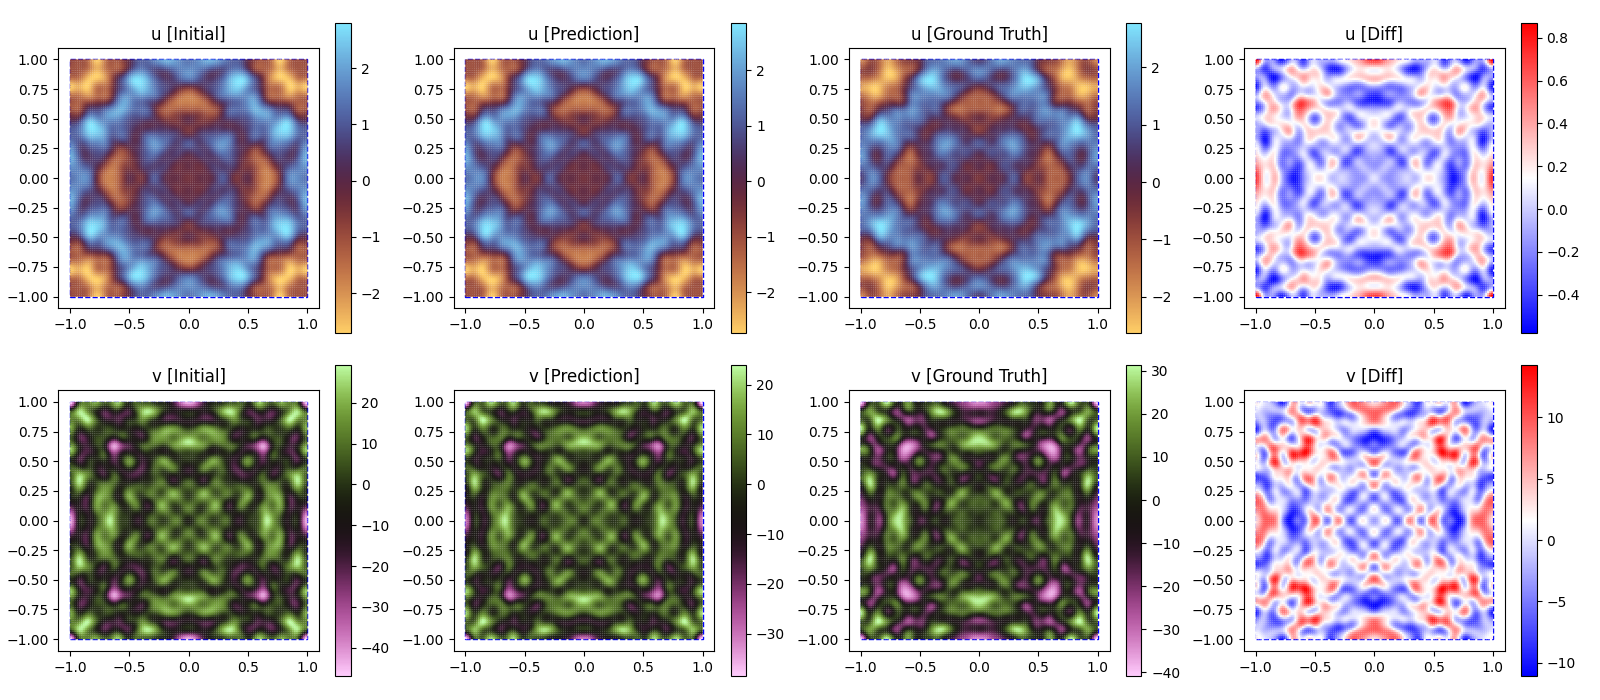

In [31]:
fig, axis = plt.subplots(2,4, figsize=(16, 7), squeeze=False)

markerSize = 0.5

uInitial = visualizeParticles(fig, axis[0,0], waveSystem.systemState, config['domain'], waveSystem.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Initial]')
vInitial = visualizeParticles(fig, axis[1,0], waveSystem.systemState, config['domain'], waveSystem.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Initial]')

uPlotRk4 = visualizeParticles(fig, axis[0,1], waveSystem.systemState, config['domain'], waveSystemNext.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Prediction]')
vPlotRk4 = visualizeParticles(fig, axis[1,1], waveSystem.systemState, config['domain'], waveSystemNext.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Prediction]')


uDiff = waveSystem.waveState.u - trajectory[0,:,0]
vDiff = waveSystem.waveState.v - trajectory[0,:,1]

uDiff = trajectory[0,:,0]
vDiff = trajectory[0,:,1]

uPlotGT = visualizeParticles(fig, axis[0,2], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Ground Truth]')
vPlotGT = visualizeParticles(fig, axis[1,2], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Ground Truth]')

diffU = (waveSystemNext.waveState.u - trajectory[0,:,0])#.detach().cpu().numpy()
diffV = (waveSystemNext.waveState.v - trajectory[0,:,1])#.detach().cpu().numpy()

visualizeParticles(fig, axis[0,3], waveSystem.systemState, config['domain'], diffU, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'bwr', markerSize = markerSize, gridVisualization = False, title = 'u [Diff]')
visualizeParticles(fig, axis[1,3], waveSystem.systemState, config['domain'], diffV, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'bwr', markerSize = markerSize, gridVisualization = False, title = 'v [Diff]')


fig.tight_layout()
fig.savefig(os.path.join(outputDir, 'prediction.png'), dpi=300)


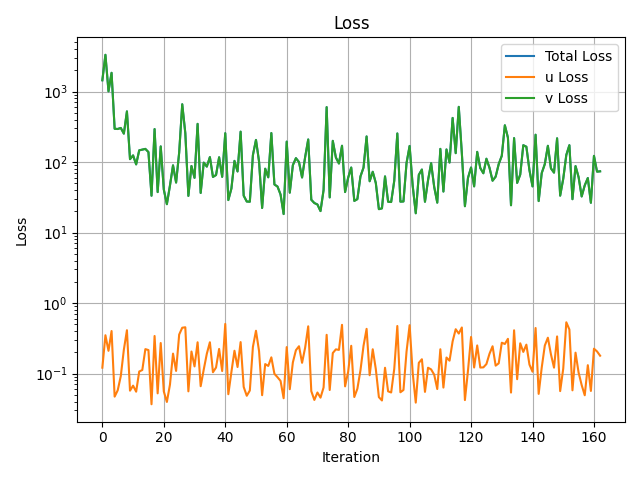

In [32]:
fig, axis = plt.subplots(1, 1)
axis.plot(losses, label='Total Loss')
axis.plot([u for u in uLosses], label='u Loss')
axis.plot([v for v in vLosses], label='v Loss')
axis.set_yscale('log')
axis.set_title('Loss')
axis.set_xlabel('Iteration')
axis.set_ylabel('Loss')
axis.grid(True)
axis.legend()

fig.tight_layout()
fig.savefig(os.path.join(outputDir, 'loss.png'), dpi=300)

In [33]:
frameStart = datasetLoader.dataset[24]

def unsq(t: Union[torch.Tensor, float, int], device) -> torch.Tensor:
    # print(f'Unsq input: {t}, type: {type(t)}')
    if isinstance(t, torch.Tensor):
        return t.unsqueeze(0)
    elif isinstance(t, str):
        return t
    else:
        return torch.tensor([t], device=device)
    

def batchifyFrame(frame):
    historyState, targetState, currentState, positions, densities, supports, volumes, dt, scheme, fileNames, simIndex, startingPoint = frame
    device = historyState.device
    
    batch = (
        unsq(historyState, device),
        unsq(targetState, device),
        unsq(currentState, device),
        unsq(positions, device),
        unsq(densities, device),
        unsq(supports, device),
        unsq(volumes, device),
        unsq(dt, device),
        unsq(scheme, device),
        unsq(fileNames, device),
        unsq(simIndex, device),        unsq(startingPoint, device),
    )
    
    return batch

batchedFrame = batchifyFrame(frameStart)

0it [00:00, ?it/s]

In [62]:
waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(batchedFrame)
eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

n = waveSystem.waveState.u.shape[0]
nx = int(n**0.5)
# print(f'Assuming square grid with nx={nx}, ny={nx}')
domainArea = (config['domain'].max[0] - config['domain'].min[0]) * (config['domain'].max[1] - config['domain'].min[1])
# print(f'Particle area: {domainArea/n}, particle spacing: {(domainArea/n)**0.5}')
dx = (domainArea/n)**0.5


waveSystemEuler = copyWaveSystem(waveSystem)
waveSystemRK4 = copyWaveSystem(waveSystem)
waveSystemNeural = copyWaveSystem(waveSystem)

with torch.no_grad():
    historyState, targetState, currentState, *_ = data
    inputFeatures, trajFeatures = processFeatures(historyState, targetState, currentState, includeC=args.includeC, includeDamping=args.includeDamping, verbose=False)
# print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')

# inputFeatures2 = inputFeatures.flatten(0,1).flatten(-2)
# inputFeatures = inputFeatures[:,:,:-1,:]

        # fi_nn = GNN(waveSystemNext.systemState, waveSystemNext.neighborhood, flattenedSelectedFeatures)

for i in range(1):
    waveSystemEuler, updates =  eulerIntegrator.function(
        waveSystemEuler,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )
    waveSystemRK4, updates = RK4Integrator.function(
        waveSystemRK4,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,    
    )
# 
    waveSystemNext = copyWaveSystem(waveSystemNeural)

    features = torch.cat([
        waveSystemNext.waveState.u.view(-1, 1),
        waveSystemNext.waveState.v.view(-1, 1),
    ], dim=-1)


    # The features are a history of the past states concatenated with the current state
    if args.includeC and args.includeDamping:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
            waveSystemNext.waveState.c.view(-1, 1),
            waveSystemNext.waveState.damping.view(-1, 1),
        ], dim=-1)
    elif args.includeC and not args.includeDamping:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
            waveSystemNext.waveState.c.view(-1, 1),
        ], dim=-1)
    elif not args.includeC and args.includeDamping:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
            waveSystemNext.waveState.damping.view(-1, 1),
        ], dim=-1)
    else:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
        ], dim=-1)
    currentFeatures = currentFeatures.unsqueeze(1).unsqueeze(0)
    # print(f'Current features shape: {currentFeatures.shape}')
    inputFeatures = torch.cat([inputFeatures, currentFeatures], dim=2)
    # print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')

    selectedFeatures = inputFeatures[:,:,-args.historyLength-1:,:]
    # print(f'Selected features shape: {selectedFeatures.shape}')
    flattenedSelectedFeatures = selectedFeatures.reshape(selectedFeatures.shape[0], selectedFeatures.shape[1], -1).flatten(0,1)
    # print(f'Flattened selected features shape: {flattenedSelectedFeatures.shape}')

    with torch.no_grad():
        fi_nn = GNN(waveSystemNext.systemState, waveSystemNext.neighborhood, flattenedSelectedFeatures)

    dudt = fi_nn[:, 0]
    dvdt = fi_nn[:, 1]

    waveSystemNeural.waveState.u = waveSystemNext.waveState.u + dudt
    waveSystemNeural.waveState.v = waveSystemNext.waveState.v + dvdt / dt
    
    

0it [00:00, ?it/s]

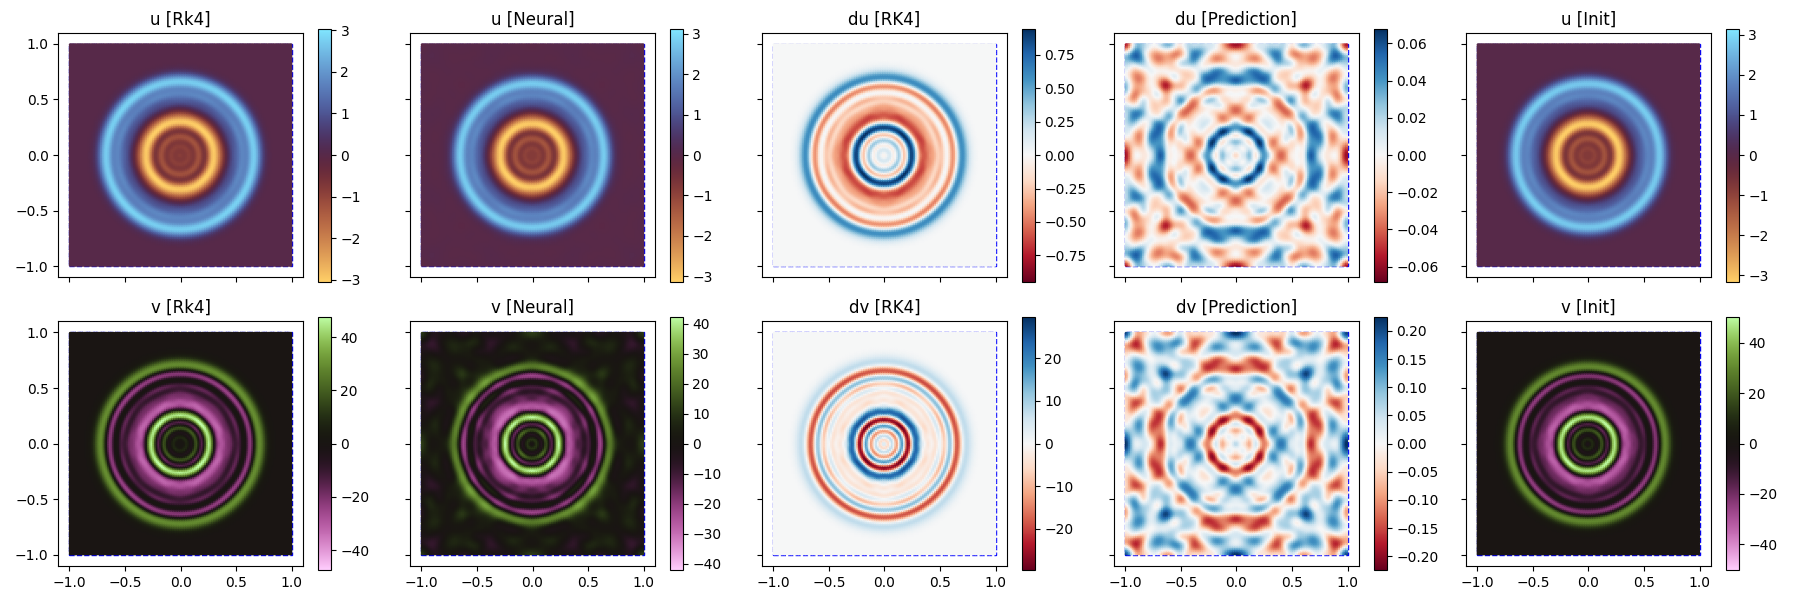

In [ ]:
fig, axis = plt.subplots(2, 5, figsize=(18,6), sharex=True, sharey=True)

markerSize = 1.5

uMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.u)).cpu().detach().item()
vMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.v)).cpu().detach().item()

uPlotRk4 = visualizeParticles(fig, axis[0,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4]', vmin = -uMaxRk4, vmax = uMaxRk4)
vPlotRk4 = visualizeParticles(fig, axis[1,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4]', vmin = -vMaxRk4, vmax = vMaxRk4)


umaxEuler = torch.max(torch.abs(waveSystemNeural.waveState.u)).cpu().detach().item()
vmaxEuler = torch.max(torch.abs(waveSystemNeural.waveState.v)).cpu().detach().item()

uPlotEuler = visualizeParticles(fig, axis[0,1], waveSystem.systemState, config['domain'], waveSystemNeural.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Neural]', vmin = -umaxEuler, vmax = umaxEuler)
vPlotEuler = visualizeParticles(fig, axis[1,1], waveSystem.systemState, config['domain'], waveSystemNeural.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Neural]', vmin = -vmaxEuler, vmax = vmaxEuler)

uDiff = (waveSystemRK4.waveState.u - waveSystemNeural.waveState.u)
vDiff = (waveSystemRK4.waveState.v - waveSystemNeural.waveState.v)

uDiff = torch.stack([u.dudt for u in updates], dim=0).mean(dim=0) * dt
vDiff = torch.stack([u.dvdt for u in updates], dim=0).mean(dim=0) * dt

uDiffVmax = torch.max(torch.abs(uDiff)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiff)).cpu().detach().item()

uPlotDiff = visualizeParticles(fig, axis[0,2], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'du [RK4]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiff = visualizeParticles(fig, axis[1,2], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'dv [RK4]', vmin = -vDiffVmax, vmax = vDiffVmax)

# uDiff = (waveSystemRK4.waveState.u - waveSystem.waveState.u)
# vDiff = (waveSystemRK4.waveState.v - waveSystem.waveState.v)
uDiffNN = fi_nn[:, 0]
vDiffNN = fi_nn[:, 1]

uDiffVmax = torch.max(torch.abs(uDiffNN)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiffNN)).cpu().detach().item()

uPlotDiffInitial = visualizeParticles(fig, axis[0,3], waveSystem.systemState, config['domain'], uDiffNN, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'du [Prediction]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiffInitial = visualizeParticles(fig, axis[1,3], waveSystem.systemState, config['domain'], vDiffNN, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'dv [Prediction]', vmin = -vDiffVmax, vmax = vDiffVmax)

errU = uDiff - uDiffNN
errV = vDiff - vDiffNN

errU = waveSystem.waveState.u
errV = waveSystem.waveState.v

errUmax = torch.max(torch.abs(errU)).cpu().detach().item()
errVmax = torch.max(torch.abs(errV)).cpu().detach().item()

uPlotError = visualizeParticles(fig, axis[0,4], waveSystem.systemState, config['domain'], errU, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Init]', vmin = -errUmax, vmax = errUmax)
vPlotError = visualizeParticles(fig, axis[1,4], waveSystem.systemState, config['domain'], errV, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Init]', vmin = -errVmax, vmax = errVmax)


fig.tight_layout()
fig.savefig(os.path.join(outputDir, 'prediction_comparison.png'), dpi=300)

In [64]:
waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(batchedFrame)
eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

n = waveSystem.waveState.u.shape[0]
nx = int(n**0.5)
# print(f'Assuming square grid with nx={nx}, ny={nx}')
domainArea = (config['domain'].max[0] - config['domain'].min[0]) * (config['domain'].max[1] - config['domain'].min[1])
# print(f'Particle area: {domainArea/n}, particle spacing: {(domainArea/n)**0.5}')
dx = (domainArea/n)**0.5


waveSystemEuler = copyWaveSystem(waveSystem)
waveSystemRK4 = copyWaveSystem(waveSystem)
waveSystemNeural = copyWaveSystem(waveSystem)

with torch.no_grad():
    historyState, targetState, currentState, *_ = data
    inputFeatures, trajFeatures = processFeatures(historyState, targetState, currentState, includeC=args.includeC, includeDamping=args.includeDamping, verbose=False)
# print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')

# inputFeatures2 = inputFeatures.flatten(0,1).flatten(-2)
# inputFeatures = inputFeatures[:,:,:-1,:]

        # fi_nn = GNN(waveSystemNext.systemState, waveSystemNext.neighborhood, flattenedSelectedFeatures)

for i in range(16):
    waveSystemEuler, updates =  eulerIntegrator.function(
        waveSystemEuler,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )
    waveSystemRK4, updates = RK4Integrator.function(
        waveSystemRK4,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,    
    )
# 
    waveSystemNext = copyWaveSystem(waveSystemNeural)

    features = torch.cat([
        waveSystemNext.waveState.u.view(-1, 1),
        waveSystemNext.waveState.v.view(-1, 1),
    ], dim=-1)


    # The features are a history of the past states concatenated with the current state
    if args.includeC and args.includeDamping:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
            waveSystemNext.waveState.c.view(-1, 1),
            waveSystemNext.waveState.damping.view(-1, 1),
        ], dim=-1)
    elif args.includeC and not args.includeDamping:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
            waveSystemNext.waveState.c.view(-1, 1),
        ], dim=-1)
    elif not args.includeC and args.includeDamping:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
            waveSystemNext.waveState.damping.view(-1, 1),
        ], dim=-1)
    else:
        currentFeatures = torch.cat([
            waveSystemNext.waveState.u.view(-1, 1),
            waveSystemNext.waveState.v.view(-1, 1),
        ], dim=-1)
    currentFeatures = currentFeatures.unsqueeze(1).unsqueeze(0)
    # print(f'Current features shape: {currentFeatures.shape}')
    inputFeatures = torch.cat([inputFeatures, currentFeatures], dim=2)
    # print(f'Input features shape: {inputFeatures.shape}, Trajectory features shape: {trajFeatures.shape}')

    selectedFeatures = inputFeatures[:,:,-args.historyLength-1:,:]
    # print(f'Selected features shape: {selectedFeatures.shape}')
    flattenedSelectedFeatures = selectedFeatures.reshape(selectedFeatures.shape[0], selectedFeatures.shape[1], -1).flatten(0,1)
    # print(f'Flattened selected features shape: {flattenedSelectedFeatures.shape}')

    with torch.no_grad():
        fi_nn = GNN(waveSystemNext.systemState, waveSystemNext.neighborhood, flattenedSelectedFeatures)

    dudt = fi_nn[:, 0]
    dvdt = fi_nn[:, 1]

    waveSystemNeural.waveState.u = waveSystemNext.waveState.u + dudt
    waveSystemNeural.waveState.v = waveSystemNext.waveState.v + dvdt / dt
    
    

0it [00:00, ?it/s]

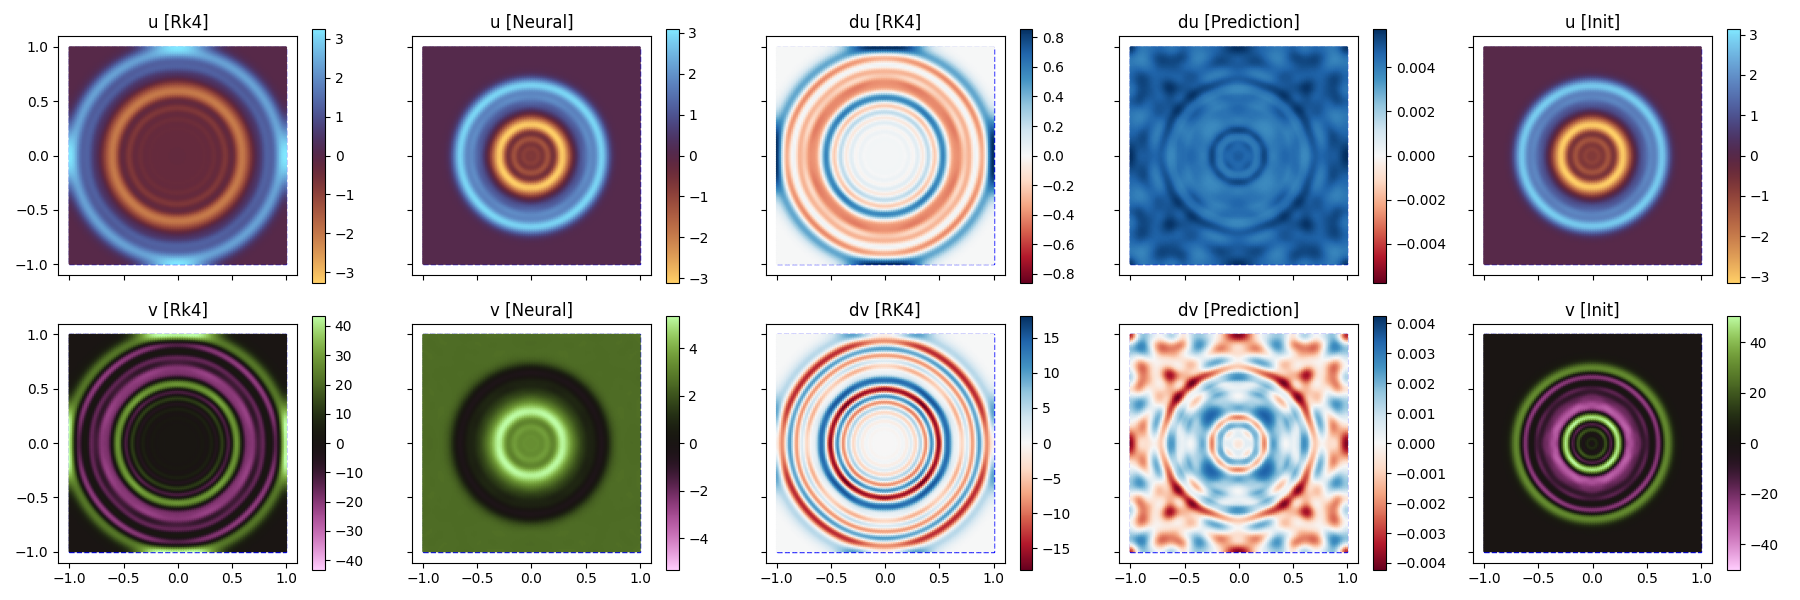

: 

In [ ]:
fig, axis = plt.subplots(2, 5, figsize=(18,6), sharex=True, sharey=True)

markerSize = 1.5

uMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.u)).cpu().detach().item()
vMaxRk4 = torch.max(torch.abs(waveSystemRK4.waveState.v)).cpu().detach().item()

uPlotRk4 = visualizeParticles(fig, axis[0,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Rk4]', vmin = -uMaxRk4, vmax = uMaxRk4)
vPlotRk4 = visualizeParticles(fig, axis[1,0], waveSystem.systemState, config['domain'], waveSystemRK4.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Rk4]', vmin = -vMaxRk4, vmax = vMaxRk4)


umaxEuler = torch.max(torch.abs(waveSystemNeural.waveState.u)).cpu().detach().item()
vmaxEuler = torch.max(torch.abs(waveSystemNeural.waveState.v)).cpu().detach().item()

uPlotEuler = visualizeParticles(fig, axis[0,1], waveSystem.systemState, config['domain'], waveSystemNeural.waveState.u, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Neural]', vmin = -umaxEuler, vmax = umaxEuler)
vPlotEuler = visualizeParticles(fig, axis[1,1], waveSystem.systemState, config['domain'], waveSystemNeural.waveState.v, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Neural]', vmin = -vmaxEuler, vmax = vmaxEuler)

uDiff = (waveSystemRK4.waveState.u - waveSystemNeural.waveState.u)
vDiff = (waveSystemRK4.waveState.v - waveSystemNeural.waveState.v)

uDiff = torch.stack([u.dudt for u in updates], dim=0).mean(dim=0) * dt
vDiff = torch.stack([u.dvdt for u in updates], dim=0).mean(dim=0) * dt

uDiffVmax = torch.max(torch.abs(uDiff)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiff)).cpu().detach().item()

uPlotDiff = visualizeParticles(fig, axis[0,2], waveSystem.systemState, config['domain'], uDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'du [RK4]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiff = visualizeParticles(fig, axis[1,2], waveSystem.systemState, config['domain'], vDiff, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'dv [RK4]', vmin = -vDiffVmax, vmax = vDiffVmax)

# uDiff = (waveSystemRK4.waveState.u - waveSystem.waveState.u)
# vDiff = (waveSystemRK4.waveState.v - waveSystem.waveState.v)
uDiffNN = fi_nn[:, 0]
vDiffNN = fi_nn[:, 1]

uDiffVmax = torch.max(torch.abs(uDiffNN)).cpu().detach().item()
vDiffVmax = torch.max(torch.abs(vDiffNN)).cpu().detach().item()

uPlotDiffInitial = visualizeParticles(fig, axis[0,3], waveSystem.systemState, config['domain'], uDiffNN, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'du [Prediction]', vmin = -uDiffVmax, vmax = uDiffVmax)
vPlotDiffInitial = visualizeParticles(fig, axis[1,3], waveSystem.systemState, config['domain'], vDiffNN, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu', markerSize = markerSize, gridVisualization = False, title = 'dv [Prediction]', vmin = -vDiffVmax, vmax = vDiffVmax)

errU = uDiff - uDiffNN
errV = vDiff - vDiffNN

errU = waveSystem.waveState.u
errV = waveSystem.waveState.v

errUmax = torch.max(torch.abs(errU)).cpu().detach().item()
errVmax = torch.max(torch.abs(errV)).cpu().detach().item()

uPlotError = visualizeParticles(fig, axis[0,4], waveSystem.systemState, config['domain'], errU, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'managua', markerSize = markerSize, gridVisualization = False, title = 'u [Init]', vmin = -errUmax, vmax = errUmax)
vPlotError = visualizeParticles(fig, axis[1,4], waveSystem.systemState, config['domain'], errV, config['kernel'], which = 'both', visualizeBoth = True, cbar = True, cmap = 'vanimo', markerSize = markerSize, gridVisualization = False, title = 'v [Init]', vmin = -errVmax, vmax = errVmax)


fig.tight_layout()
fig.savefig(os.path.join(outputDir, 'prediction_comparison_16steps.png'), dpi=300)